#Objetivo
En esta etapa se aplica el Análisis de Componentes Principales (PCA) para reducir la dimensionalidad de las variables numéricas del conjunto de datos, conservando la mayor cantidad posible de información. Esto permite identificar patrones entre las variables y facilitar la interpretación del comportamiento de los usuarios con mayor tiempo de visualización

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Se importan las bibliotecas necesarias para realizar el escalamiento de las variables, aplicar el PCA y visualizar los resultados.

In [ ]:
from google.colab import files
upload = files.upload()

Saving dataset,processed.json to dataset,processed.json


In [ ]:
import io


file_name = list(upload.keys())[0]


df = pd.read_json(io.BytesIO(upload[file_name]))

Se carga el conjunto de datos previamente limpio que será utilizado para realizar el análisis de componentes principales.

In [ ]:
df.head()

,id_usuario,edad,plan_suscripcion,minutos_visualizacion_mensual,pais,genero_favorito,fecha_ultimo_inicio_sesion,tickets_soporte_cliente
0,10000,39,Estándar,805.8,Brasil,Crime,1741046400000,99
1,10001,37,Estándar,1173.4,Colombia,Crime,1554163200000,2
2,10002,28,Básico,401.0,Colombia,Crime,1523577600000,0
3,10003,43,Básico,62.4,Uruguay,Thriller,1612051200000,0
4,10004,51,Básico,477.8,Perú,Thriller,1601424000000,1


In [ ]:
variables = df[
    [
        "edad",
        "minutos_visualizacion_mensual",
        "tickets_soporte_cliente"
    ]
]

variables.head()

,edad,minutos_visualizacion_mensual,tickets_soporte_cliente
0,39,805.8,99
1,37,1173.4,2
2,28,401.0,0
3,43,62.4,0
4,51,477.8,1


Se visualiza la estructura del dataframe y luego solo las columnas numericas que se utilizaran pra el PCA

In [ ]:
scaler = StandardScaler()

variables_escaladas = scaler.fit_transform(variables)

Antes de aplicar el PCA es necesario escalar las variables debido a que presentan diferentes unidades de medida. El método StandardScaler estandariza cada variable para que tenga media igual a 0 y desviación estándar igual a 1, evitando que una variable con valores más grandes tenga mayor influencia en el análisis.

In [ ]:
pca = PCA()

componentes = pca.fit_transform(variables_escaladas)

Se aplica el algoritmo PCA sobre las variables escaladas con el objetivo de obtener nuevas variables denominadas componentes principales, las cuales concentran la mayor cantidad posible de información presente en los datos originales.

In [ ]:
varianza = pd.DataFrame({

    "Componente":

    range(1, len(pca.explained_variance_ratio_) + 1),

    "Varianza explicada":

    pca.explained_variance_ratio_,

    "Varianza acumulada":

    pca.explained_variance_ratio_.cumsum()

})

varianza

,Componente,Varianza explicada,Varianza acumulada
0,1,0.336508,0.336508
1,2,0.333937,0.670446
2,3,0.329554,1.000000


Se calcula la proporción de la variabilidad explicada por cada componente principal. La varianza acumulada permite determinar cuántas componentes son necesarias para conservar la mayor parte de la información del conjunto de datos.

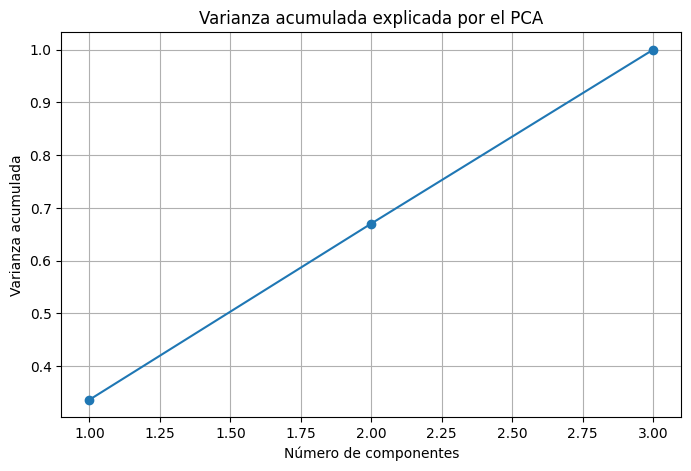

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(

    range(1, len(pca.explained_variance_ratio_) + 1),

    pca.explained_variance_ratio_.cumsum(),

    marker="o"

)

plt.title("Varianza acumulada explicada por el PCA")

plt.xlabel("Número de componentes")

plt.ylabel("Varianza acumulada")

plt.grid(True)

plt.show()

Este grafico muestra la varianza acumulada explicada por un Análisis de Componentes Principales (PCA). En el eje X está el número de componentes principales (1, 2, 3) y en el eje Y el porcentaje acumulado de varianza del dataset original que esos componentes logran capturar.

Se observa lo siguiente:

- Con 1 componente, se explica aproximadamente el 35%* de la varianza total de los datos.
- Con 2 componentes, se explica cerca del 68-70%.
- Con 3 componentes, se explica aproximadamente el 100% (lógico, ya que el dataset original tiene solo 3 variables numéricas).

Interpretación

- La curva no muestra un "codo" muy marcado, sube de forma bastante lineal, lo que sugiere que las 3 variables originales aportan información relativamente similar entre sí, sin mucha redundancia.
- Para retener al menos 80-90% de la varianza (regla común en PCA), acá necesitamos los 3 componentes, es decir, en este caso PCA no permite reducir mucho la dimensionalidad sin perder información relevante, porque con solo 2 componentes se queda en 70%.
- Esto tiene sentido para la conclusión anterior: ya que edad, plan y minutos de visualización aportan cada una información relativamente independiente sobre el perfil del usuario (ninguna variable "contiene" a la otra), así que no sorprende que el PCA necesite casi todas las dimensiones para explicar bien los datos.

En conclusion este gráfico dice que no conviene reducir a 1 o 2 componentes porque se perdería bastante información (30% en el caso de 2). Con solo 3 variables numéricas de entrada, probablemente no haga falta aplicar PCA, esto tiene más sentido cuando se tiene muchas variables correlacionadas entre sí.

In [ ]:
componentes_df = pd.DataFrame(

    pca.components_,

    columns=variables.columns,

    index=[

        f"CP{i+1}"

        for i in range(len(variables.columns))

    ]

)

componentes_df

,edad,minutos_visualizacion_mensual,tickets_soporte_cliente
CP1,0.111160,0.721764,-0.683155
CP2,0.917931,0.188866,0.348902
CP3,-0.380849,0.665873,0.641535


Interpretación de los componentes principales (PCA)

El Análisis de Componentes Principales (PCA) se aplicó sobre las variables numéricas edad, minutos de visualización mensual y tickets de soporte al cliente, con el fin de identificar combinaciones lineales que resuman la variabilidad del dataset.

Los resultados muestran que:

-CP1 está determinado principalmente por los minutos de visualización mensual (carga de 0.72) y, en sentido opuesto, por los tickets de soporte al cliente (carga de -0.68), con escasa influencia de la edad. Este componente puede interpretarse como un eje que contrapone el nivel de consumo de contenido con el nivel de reclamos generados por el usuario.

-CP2 está explicado casi en su totalidad por la variable edad (carga de 0.92), constituyendo prácticamente un eje etario independiente de las demás variables.

-CP3 combina las tres variables con pesos moderados, oponiendo la edad (carga de -0.38) al consumo y los tickets de soporte, que presentan cargas similares y de igual signo (0.67 y 0.64 respectivamente).

Cabe destacar que, dado que las tres variables originales presentan una correlación relativamente baja entre sí, el PCA no logró concentrar la varianza en uno o dos componentes: se requieren los tres componentes principales para explicar aproximadamente el 100% de la varianza total del dataset (según lo observado en el gráfico de varianza acumulada). Esto indica que, si bien la técnica permitió identificar patrones de asociación entre las variables, no resultó eficaz como método de reducción de dimensionalidad para este conjunto de datos particular.